<a href="https://colab.research.google.com/github/RapoluUma956/Navigation-and-Sensor-data-error-minimization-using-AI/blob/main/LSTM_attitude_Estimation_2/LSTM_Attitude_Estimation_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [63]:
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, Conv1D, RNN, SimpleRNN
from tensorflow.keras.layers import GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Bidirectional
from sklearn import preprocessing
from tensorflow.keras import regularizers
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import numpy as np
import re
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import math
from scipy.io import loadmat
import time

## **Import Data**

In [74]:
df = pd.read_excel('/content/drive/MyDrive/LSTM-DRDO/D6.xlsx')
df.head()
data1=np.array(df)
print(data1.shape)
data=data1[0:data1.shape[0],:]
print(data.shape)

(34862, 12)
(34862, 12)


In [75]:
dataX = data[:,0:9];
dataY = data[:,9:12]

In [76]:
split = 10000
# train-test split first
dataXt = dataX[:split]
dataYt = dataY[:split]

dataXv = dataX[split:]
dataYv = dataY[split:]

# scaler fitted only on training input data
x_scaler = MinMaxScaler()

dataXt = x_scaler.fit_transform(dataXt)
dataXv = x_scaler.transform(dataXv)

input_dim = dataXt.shape[1]

print("input_dim:", input_dim)
print("\nTraining Testing")
print(dataXt.shape[0],dataXv.shape[0])

timestep = 2
Xphithetapsi = dataXt
Xphithetapsi = array(Xphithetapsi).reshape(split//timestep, timestep, input_dim)
Yphithetapsi = array(dataYt[0::timestep])
print("Xphithetapsi shape",Xphithetapsi.shape)
print("Yphithetapsi shape",Yphithetapsi.shape)

input_dim: 9

Training Testing
10000 24862
Xphithetapsi shape (5000, 2, 9)
Yphithetapsi shape (5000, 3)


## **Split Training and Testing Data**

In [77]:
input_dim = dataXt.shape[1]

print("input_dim:", input_dim)
print("\nTraining Testing")
print(dataXt.shape[0],dataXv.shape[0])

timestep = 2
Xphithetapsi = dataXt
Xphithetapsi = array(Xphithetapsi).reshape(split//timestep, timestep, input_dim)
Yphithetapsi = array(dataYt[0::timestep])
print("Xphithetapsi shape",Xphithetapsi.shape)
print("Yphithetapsi shape",Yphithetapsi.shape)

input_dim: 9

Training Testing
10000 24862
Xphithetapsi shape (5000, 2, 9)
Yphithetapsi shape (5000, 3)


## **Model desing and Training**

In [78]:
inputs = Input(name='inputs',shape=[timestep,input_dim])
layer = LSTM(50, return_sequences=True)(inputs)
layer = Dropout(0.25)(layer)
layer = LSTM(20)(layer)
outputs = Dense(3, activation='linear')(layer)

modelphithetapsi1 = Model(inputs=[inputs],outputs=[outputs])

# Compile
modelphithetapsi1.compile(optimizer='Adam', loss='mean_squared_error',metrics = ['accuracy'])
modelphithetapsi1.summary()

history = modelphithetapsi1.fit(Xphithetapsi, Yphithetapsi,
                       epochs=20,
                       verbose=0,
                       batch_size=50)

print('Model Training done')

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

Model Training done


## **Offline Predictions**

In [79]:
results = []

Xtestt = dataXv
Ytestt = dataYv

usable_len = (len(Xtestt) // timestep) * timestep

Xtestt = Xtestt[:usable_len]
Ytestt = Ytestt[:usable_len]

Ytest = np.array(Ytestt[0::timestep])
Xtest = np.array(Xtestt[:, 0:9])

ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

test_output = modelphithetapsi1.predict(ip)

results = np.array(test_output)
print("results shape:", results.shape)
print("Ytest shape:", Ytest.shape)

389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
results shape: (12431, 3)
Ytest shape: (12431, 3)


## **Incremental Learning Model**

In [80]:
# new model for incremental learning
model = Model(inputs=[inputs],outputs=[outputs])
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)
model.summary()
#copy weights
Wsave = modelphithetapsi1.get_weights()
model.set_weights(Wsave)

wgt = model.get_weights()
print(wgt[1])

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

[[ 0.15208434  0.49593443  0.28784114 ... -0.08826333  0.10424919
   0.14880793]
 [ 0.04160754  0.4188312   0.1681564  ...  0.16930227  0.03510392
  -0.06857197]
 [ 0.29102924  0.2562017   0.29988885 ... -0.07119013  0.20824298
   0.24641177]
 ...
 [ 0.02377995  0.42108923  0.16645366 ...  0.02385423  0.27902508
  -0.02165968]
 [-0.1531972  -0.32249373 -0.16539869 ...  0.21840805 -0.07164375
   0.0233955 ]
 [-0.19257009 -0.2956836  -0.26824886 ...  0.1632591  -0.16477363
  -0.27379012]]


In [81]:
result = []

stepinit = 3000
timestep = 2
input_dim = 9

total_test_rows = dataXv.shape[0]
num_chunks = total_test_rows // stepinit
araya = [stepinit] * num_chunks

print("Total test rows:", total_test_rows)
print("Full chunks:", num_chunks)

for j in range(num_chunks):
    pt = stepinit * j

    Xtestt = dataXv[pt:pt + stepinit]
    Ytestt = dataYv[pt:pt + stepinit]

    usable_len = (len(Xtestt) // timestep) * timestep

    Xtestt = Xtestt[:usable_len]
    Ytestt = Ytestt[:usable_len]

    Xtest = np.array(Xtestt[:, 0:9])
    Ytest = np.array(Ytestt[0::timestep])

    ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

    test_output = model.predict(ip)
    result.append(test_output)

    start = time.time()
    history = model.fit(
        ip,
        Ytest,
        epochs=20,
        verbose=0,
        batch_size=50
    )
    end = time.time()

    print("Training time:", end - start)

if len(result) > 0:
    result = np.vstack(result)
else:
    result = np.empty((0, 3))

print("result shape:", result.shape)


# remaining data block
result1 = []

pt = stepinit * num_chunks
step = total_test_rows - pt

print("Remaining step:", step)

if step > 0:
    Xtestt = dataXv[pt:pt + step]
    Ytestt = dataYv[pt:pt + step]

    usable_len = (len(Xtestt) // timestep) * timestep

    if usable_len > 0:
        Xtestt = Xtestt[:usable_len]
        Ytestt = Ytestt[:usable_len]

        Xtest = np.array(Xtestt[:, 0:9])
        Ytest = np.array(Ytestt[0::timestep])

        ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

        test_output = model.predict(ip)
        result1.append(test_output)

        result1 = np.vstack(result1)
    else:
        result1 = np.empty((0, 3))
else:
    result1 = np.empty((0, 3))

print("result1 shape:", result1.shape)


# combine both
if result1.shape[0] > 0:
    results = np.vstack((result, result1))
else:
    results = result

print("Final results shape:", results.shape)

Total test rows: 24862
Full chunks: 8
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Training time: 6.1795713901519775
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.692072153091431
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training time: 5.223411560058594
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.284891128540039
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.211133241653442
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training time: 4.452785968780518
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 4.104856967926025
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.700718402862549
result shape: (12000, 3)
Remaining step: 862
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
result1 shape: (431, 3)
Final results shape: (12431, 3)


In [82]:
print(result.shape)
print(result1.shape)

results = np.vstack((result,result1))
print(results.shape)

(12000, 3)
(431, 3)
(12431, 3)


## **Compute RMSE and Print Results**

Yt shape: (12431, 3)
test_output shape: (12431, 3)
Final Yt shape: (12431, 3)
Final test_output shape: (12431, 3)
RMSE phi/roll: 1.152211333089697
RMSE theta/pitch: 0.5020653233136805
RMSE psi/yaw: 1.0305427706956563
MAE phi/roll: 0.4855310554464779
MAE theta/pitch: 0.2664251882619491
MAE psi/yaw: 0.5116813600178147
R2 phi/roll: 0.6173185698285257
R2 theta/pitch: 0.625534727167548
R2 psi/yaw: 0.4753440557657208


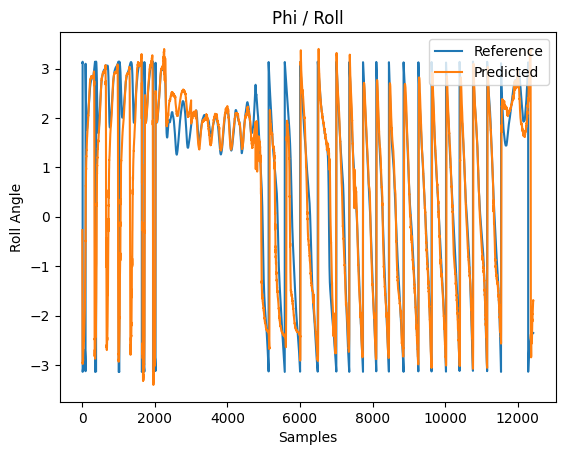

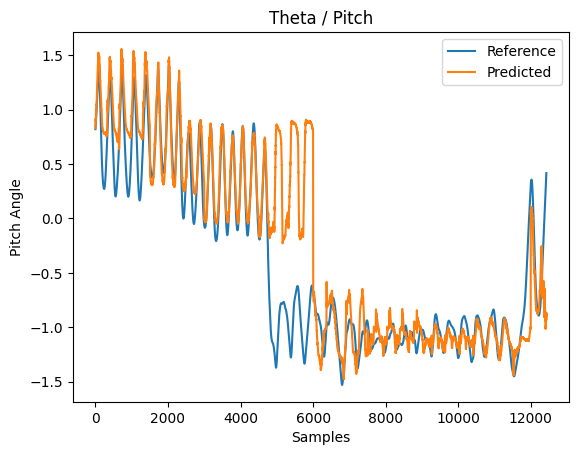

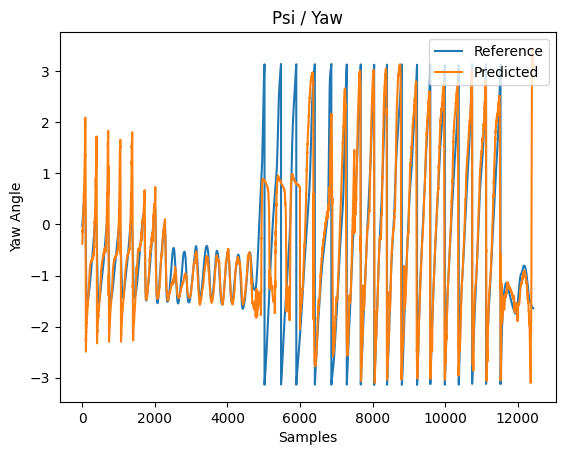

In [83]:
Yt = np.array(dataYv[0::timestep])
test_output = np.array(results)

print("Yt shape:", Yt.shape)
print("test_output shape:", test_output.shape)

# match lengths
min_len = min(Yt.shape[0], test_output.shape[0])

Yt = Yt[:min_len]
test_output = test_output[:min_len]

print("Final Yt shape:", Yt.shape)
print("Final test_output shape:", test_output.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

rmsephi = sqrt(mean_squared_error(Yt[:, 0], test_output[:, 0]))
rmsetheta = sqrt(mean_squared_error(Yt[:, 1], test_output[:, 1]))
rmsepsi = sqrt(mean_squared_error(Yt[:, 2], test_output[:, 2]))

maephi = mean_absolute_error(Yt[:, 0], test_output[:, 0])
maetheta = mean_absolute_error(Yt[:, 1], test_output[:, 1])
maepsi = mean_absolute_error(Yt[:, 2], test_output[:, 2])

r2phi = r2_score(Yt[:, 0], test_output[:, 0])
r2theta = r2_score(Yt[:, 1], test_output[:, 1])
r2psi = r2_score(Yt[:, 2], test_output[:, 2])

print("RMSE phi/roll:", rmsephi)
print("RMSE theta/pitch:", rmsetheta)
print("RMSE psi/yaw:", rmsepsi)

print("MAE phi/roll:", maephi)
print("MAE theta/pitch:", maetheta)
print("MAE psi/yaw:", maepsi)

print("R2 phi/roll:", r2phi)
print("R2 theta/pitch:", r2theta)
print("R2 psi/yaw:", r2psi)

plt.plot(Yt[:, 0])
plt.plot(test_output[:, 0])
plt.title('Phi / Roll')
plt.xlabel('Samples')
plt.ylabel('Roll Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 1])
plt.plot(test_output[:, 1])
plt.title('Theta / Pitch')
plt.xlabel('Samples')
plt.ylabel('Pitch Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 2])
plt.plot(test_output[:, 2])
plt.title('Psi / Yaw')
plt.xlabel('Samples')
plt.ylabel('Yaw Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()